In [ ]:
import numpy as np
import cv2
import os
from pathlib import Path

def yuv444_to_rgb(yuv_path, width, height, full_range=True, format='YUV'):
    """
    将YUV444文件转换为RGB格式
    :param yuv_path: YUV文件路径
    :param width: 图像宽度
    :param height: 图像高度
    :param full_range: 是否为全范围YUV（0-255），否则为电视范围（16-235）
    :param format: YUV数据顺序，支持'YUV'或'YVU'
    :return: RGB图像数组
    """
    # 计算YUV444文件大小 (Y、U、V分量尺寸相同，各为width*height)
    y_size = width * height
    yuv_size = y_size * 3  # 总大小: Y + U + V
    
    # 读取YUV数据
    yuv_data = np.fromfile(yuv_path, dtype=np.uint8)
    if yuv_data.size != yuv_size:
        raise ValueError(f"文件大小不匹配，期望 {yuv_size} 字节，实际 {yuv_data.size}")
    
    # 分离Y、U、V分量（YUV444的U、V与Y尺寸相同，无需上采样）
    y = yuv_data[0:y_size].reshape((height, width))
    u = yuv_data[y_size:y_size*2].reshape((height, width))  # U分量尺寸与Y相同
    v = yuv_data[y_size*2:].reshape((height, width))        # V分量尺寸与Y相同
    
    # 合并为YUV444格式（OpenCV转换需要）
    if format == 'YUV':
        yuv = cv2.merge([y, u, v])
    elif format == 'YVU':
        yuv = cv2.merge([y, v, u])  # YVU是Y-V-U顺序
    else:
        raise ValueError("不支持的格式，仅支持'YUV'和'YVU'")
    
    # 处理YUV范围（全范围vs电视范围）
    if not full_range:
        # 电视范围转全范围：Y: 16-235 -> 0-255，UV: 16-240 -> 0-255
        y = np.clip((y - 16) * 255 / 219, 0, 255).astype(np.uint8)
        u = np.clip((u - 128) * 255 / 224 + 128, 0, 255).astype(np.uint8)
        v = np.clip((v - 128) * 255 / 224 + 128, 0, 255).astype(np.uint8)
        if format == 'YUV':
            yuv = cv2.merge([y, u, v])
        else:
            yuv = cv2.merge([y, v, u])
    
    # 转换为RGB
    rgb = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
    
    return rgb

def batch_convert_yuv_to_bmp(
    input_dir="eval_dataset",
    output_dir="eval_dataset",
    width=1920,
    height=1280,
    full_range=True,
    format='YUV'
):
    """
    批量转换文件夹中的所有YUV文件为BMP格式（无损保存RGB数据）
    :param input_dir: 输入YUV文件所在目录
    :param output_dir: 输出BMP文件目录
    :param width: 图像宽度（所有YUV文件需统一尺寸）
    :param height: 图像高度（所有YUV文件需统一尺寸）
    :param full_range: 是否为全范围YUV
    :param format: YUV数据顺序（YUV或YVU）
    """
    # 创建输出目录（如果不存在）
    os.makedirs(output_dir, exist_ok=True)
    
    # 获取目录中所有.yuv结尾的文件
    yuv_files = list(Path(input_dir).glob("*.yuv"))
    
    if not yuv_files:
        print(f"警告：在 {input_dir} 中未找到任何.yuv文件")
        return
    
    print(f"找到 {len(yuv_files)} 个YUV文件，开始转换为BMP格式...")
    
    # 批量转换
    for idx, yuv_path in enumerate(yuv_files, 1):
        try:
            # 转换YUV到RGB
            rgb_img = yuv444_to_rgb(
                yuv_path=str(yuv_path),
                width=width,
                height=height,
                full_range=full_range,
                format=format
            )
            
            # 生成输出文件名（保持原文件名，后缀改为.bmp）
            output_filename = f"{yuv_path.stem}.bmp"
            output_path = os.path.join(output_dir, output_filename)
            
            # 保存为BMP格式（OpenCV保存BMP无需额外参数，默认无损）
            # OpenCV默认保存BGR，所以需要转换回BGR格式
            bgr_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, bgr_img)  # BMP格式默认无损保存，无需压缩参数
            
            print(f"[{idx}/{len(yuv_files)}] 成功转换: {yuv_path.name} -> {output_filename}")
        
        except Exception as e:
            print(f"[{idx}/{len(yuv_files)}] 转换失败: {yuv_path.name} - 错误: {str(e)}")
    
    print("批量转换为BMP格式完成！")

if __name__ == "__main__":
    # 配置参数（根据你的实际情况修改）
    BATCH_CONFIG = {
        "input_dir": "eval_dataset",      # 输入YUV文件夹
        "output_dir": "eval_dataset",     # 输出BMP文件夹（与输入相同）
        "width": 1920,                    # 图像宽度（必须正确）
        "height": 1280,                   # 图像高度（必须正确）
        "full_range": True,               # 是否为全范围YUV（0-255）
        "format": "YUV"                   # YUV数据顺序（YUV或YVU）
    }
    
    # 执行批量转换（输出BMP格式）
    batch_convert_yuv_to_bmp(**BATCH_CONFIG)

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips
import torch
from torch.utils.data import DataLoader, Dataset
from typing import Dict, Tuple, List, Optional
from model_freetech import RawFormer

# -------------------------- 配置参数（与训练时完全一致！） --------------------------
EVAL_DATASET_DIR = "eval_dataset"  
# EVAL_DATASET_DIR = "static"
ENHANCED_PREFIX = "enhanced_"
OUTPUT_EXCEL = "enhanced_image_evaluation.xlsx"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LPIPS_MODEL = "alex"
MODEL_SIZE = "S"  # 训练时的model_size
MODEL_DIM = 32 if MODEL_SIZE == "S" else 48 if MODEL_SIZE == "B" else 64
CHECKPOINT_PATH = "result/Freetech/weights/model_best_1.pth"  # 模型权重路径
# 数据配置（与训练时一致）
RAW_WIDTH = 1920
RAW_HEIGHT = 1280
RGB_WIDTH = 1920
RGB_HEIGHT = 1280
PATCH_SIZE = 512
RAW_HEADER_SIZE = 0  # 训练时的raw_header_size（从正确版本复制）
NORMALIZE_RANGE = (0, 1)  # 训练时的normalize_range
# ----------------------------------------------------------------

class RawRGB_Paired_RootDir(Dataset):
    def __init__(
        self,
        root_path: str,
        raw_width: int,
        raw_height: int,
        raw_header_size: int = 0,
        rgb_width: int = 1920,
        rgb_height: int = 1280,
        patch_size: int = 512,
        training: bool = False,
        normalize_range: Tuple[float, float] = (0, 1)
    ):
        self.root_path = root_path
        self.raw_width = raw_width
        self.raw_height = raw_height
        self.raw_header_size = raw_header_size
        self.rgb_width = rgb_width
        self.rgb_height = rgb_height
        self.patch_size = patch_size
        self.training = training
        self.min_val, self.max_val = normalize_range

        # 核心修改：扫描根目录下的 .raw 和 .bmp 配对（同名）
        self.raw_rgb_pairs = self._scan_rootdir_paired_files()
        if len(self.raw_rgb_pairs) == 0:
            raise ValueError(f"在 {root_path} 根目录下未找到配对的 .raw 和 .bmp 文件")

    def _scan_rootdir_paired_files(self) -> List[Tuple[str, str]]:
        """扫描根目录下的 .raw 和 .bmp 配对（文件名相同，后缀不同）"""
        paired_files = []
        # 遍历根目录所有文件
        for filename in os.listdir(self.root_path):
            if filename.lower().endswith(".raw"):
                # 提取文件名（不含后缀）
                base_name = os.path.splitext(filename)[0]
                # 对应的 .bmp GT 图路径
                rgb_filename = f"{base_name}.bmp"
                rgb_path = os.path.join(self.root_path, rgb_filename)
                raw_path = os.path.join(self.root_path, filename)
                # 检查 GT 图是否存在
                if os.path.exists(rgb_path):
                    paired_files.append((raw_path, rgb_path))
                else:
                    print(f"警告：.raw 文件 {filename} 对应的 .bmp GT 图 {rgb_filename} 不存在，跳过")
        return paired_files

    def _load_raw(self, raw_path: str) -> np.ndarray:
        """加载并预处理RAW文件（与训练时一致）"""
        with open(raw_path, 'rb') as f:
            f.seek(self.raw_header_size)
            raw_data = np.fromfile(f, dtype=np.uint16)
        # 重塑为 (H, W)，确保不超出范围
        raw_img = raw_data[:self.raw_height * self.raw_width].reshape(self.raw_height, self.raw_width)
        return raw_img.astype(np.float32)

    def _normalize_raw(self, raw_img: np.ndarray) -> np.ndarray:
        """RAW归一化（完全复刻训练公式）"""
        return raw_img.astype(np.float32) / 255.0
        # 如果需要使用训练时的黑电平处理，取消下面注释并注释上面一行
        # ap = 100  # 训练固定
        # black_level = 512  # 训练黑电平
        # max_raw = 16383  # 14-bit max
        # raw_processed = (np.maximum(raw_img.astype(np.float32) - black_level, 0) / (max_raw - black_level)) * ap
        # return raw_processed  # [H,W] float ~[0,100]（模型 clamp [0,1]）

    def _load_rgb(self, rgb_path: str) -> Tuple[np.ndarray, np.ndarray]:
        """加载GT图（完全复刻训练时的处理逻辑）"""
        bmp_img = cv2.imread(rgb_path, cv2.IMREAD_COLOR)
        bmp_img = cv2.cvtColor(bmp_img, cv2.COLOR_BGR2RGB)

        # 调整尺寸（与训练时一致）
        if bmp_img.shape[:2] != (self.rgb_height, self.rgb_width):
            bmp_img = cv2.resize(bmp_img, (self.rgb_width, self.rgb_height), interpolation=cv2.INTER_LINEAR)

        bmp_uint8 = bmp_img.astype(np.uint8)
        bmp_norm = bmp_uint8.astype(np.float32) / 255.0  # ★ 训练时唯一正确版本

        return bmp_norm, bmp_uint8

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, np.ndarray]:
        """返回 (input_raw, gt_rgb, gt_uint8)，严格复刻训练时格式"""
        raw_path, rgb_path = self.raw_rgb_pairs[idx]

        # 加载数据 - 修正：传入 raw_path 参数
        raw_img = self._load_raw(raw_path)  # 这里添加了 raw_path 参数！
        bmp_norm, bmp_uint8 = self._load_rgb(rgb_path)  # bmp_norm已是(0,1)，与训练时GT一致

        # RAW归一化（与训练时一致）
        raw_norm = self._normalize_raw(raw_img)

        # 训练时裁剪 patch，评估时用完整图
        if self.training:
            # 裁剪 patch（复用训练时的逻辑）
            h, w = raw_norm.shape
            y = np.random.randint(0, h - self.patch_size)
            x = np.random.randint(0, w - self.patch_size)
            raw_norm = raw_norm[y:y+self.patch_size, x:x+self.patch_size]
            bmp_norm = bmp_norm[y:y+self.patch_size, x:x+self.patch_size]
            bmp_uint8 = bmp_uint8[y:y+self.patch_size, x:x+self.patch_size]

        # 转换为张量（严格复刻训练时格式：RAW为(1,H,W)，RGB为(3,H,W)）
        input_raw = torch.from_numpy(raw_norm).unsqueeze(0).float()  # (1, H, W)
        gt_rgb = torch.from_numpy(bmp_norm.transpose(2, 0, 1)).float()  # (3, H, W) → 与训练时完全一致

        return input_raw, gt_rgb, bmp_uint8

    def __len__(self) -> int:
        return len(self.raw_rgb_pairs)

    @property
    def raw_paths(self) -> List[str]:
        """返回所有 RAW 文件路径（用于获取基础文件名）"""
        return [pair[0] for pair in self.raw_rgb_pairs]

# -------------------------- 模型加载（与训练时一致） --------------------------
def load_enhance_model() -> RawFormer:
    num_virtual_cams = 5  # 与训练时一致
    pretrain_mode = False
    model = RawFormer(
        dim=MODEL_DIM,
        use_rep_nr=True,
        num_virtual_cams=num_virtual_cams,
        pretrain_mode=pretrain_mode
    )
    # 加载权重
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    state_dict = checkpoint["state_dict"]
    new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict, strict=False)
    model = model.to(DEVICE)
    model.eval()
    print(f"模型已加载到 {DEVICE}，权重路径：{CHECKPOINT_PATH}")
    return model

# -------------------------- 数据加载（使用修改后的数据集类） --------------------------
def create_eval_dataset() -> Tuple[DataLoader, List[str]]:
    """用修改后的根目录数据集类加载评估数据，确保格式与训练时一致"""
    dataset = RawRGB_Paired_RootDir(
        root_path=EVAL_DATASET_DIR,
        raw_width=RAW_WIDTH,
        raw_height=RAW_HEIGHT,
        raw_header_size=RAW_HEADER_SIZE,
        rgb_width=RGB_WIDTH,
        rgb_height=RGB_HEIGHT,
        patch_size=PATCH_SIZE,
        training=False,  # 评估模式，不裁剪
        normalize_range=NORMALIZE_RANGE
    )
    dataloader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )
    # 获取基础文件名（用于保存增强图）
    base_names = [os.path.splitext(os.path.basename(f))[0] for f in dataset.raw_paths]
    return dataloader, base_names

# -------------------------- 图像增强（保持格式一致性） --------------------------
def enhance_raw_batch(input_raw: torch.Tensor, model: RawFormer, base_name: str) -> Tuple[np.ndarray, str, torch.Tensor]:
    """
    增强 RAW 图像，返回：
    - enhanced_img: 增强图的 uint8 数组（用于其他指标计算）
    - enhanced_path: 增强图保存路径
    - pred_rgb_tensor: 模型输出的张量（(1,3,H,W)，0-1 范围，用于 PSNR 计算）
    """
    with torch.no_grad():
        pred_rgb_tensor = model(input_raw, cam_id=0)
        pred_rgb_tensor = torch.clamp(pred_rgb_tensor, 0, 1)  # 与训练时一致
    
    # 转换为 uint8 用于保存和其他指标计算
    pred_rgb_np = (pred_rgb_tensor.cpu().numpy().squeeze().transpose((1, 2, 0)) * 255).astype(np.uint8)
    enhanced_path = os.path.join(EVAL_DATASET_DIR, f"{ENHANCED_PREFIX}{base_name}.bmp")
    cv2.imwrite(enhanced_path, cv2.cvtColor(pred_rgb_np, cv2.COLOR_RGB2BGR))
    print(f"增强图已保存：{os.path.basename(enhanced_path)}")
    return pred_rgb_np, enhanced_path, pred_rgb_tensor

# -------------------------- 完全复刻训练时的PSNR计算逻辑 --------------------------
def calculate_psnr_train_style(gt_rgb_tensor: torch.Tensor, pred_rgb_tensor: torch.Tensor) -> float:
    """
    100% 复刻训练时的PSNR计算：
    - 输入：gt_rgb_tensor（训练时的格式：(B,3,H,W)，值范围(0,1)）
    - 输入：pred_rgb_tensor（模型输出：(B,3,H,W)，值范围(0,1)）
    - 输出：与训练时一致的PSNR值
    """
    # 复刻训练时的维度转换和类型转换
    gt_np = gt_rgb_tensor.cpu().numpy().transpose(0, 2, 3, 1)  # (B, H, W, 3)
    pred_np = np.clip(
        pred_rgb_tensor.detach().cpu().numpy().transpose(0, 2, 3, 1),
        0.0, 1.0
    )

    # 转uint8（与训练时一致）
    gt_uint8 = (gt_np * 255).astype(np.uint8)
    pred_uint8 = (pred_np * 255).astype(np.uint8)

    # 调用skimage PSNR（与训练时完全一致，指定data_range=255）
    psnr_value = psnr(gt_uint8, pred_uint8, data_range=255)
    # 处理批次维度返回值（单样本时返回 scalar，多样本时返回数组取平均）
    return psnr_value.mean() if isinstance(psnr_value, np.ndarray) else psnr_value

# -------------------------- 其他指标计算（保持不变） --------------------------
def calculate_ssim(gt_img: np.ndarray, enhanced_img: np.ndarray) -> float:
    return ssim(
        gt_img, enhanced_img, 
        data_range=255, 
        channel_axis=2,
        gaussian_weights=True,
        sigma=1.5
    )

def calculate_lpips(gt_img: np.ndarray, enhanced_img: np.ndarray, lpips_model) -> float:
    def preprocess(img: np.ndarray) -> torch.Tensor:
        img_norm = (img / 255.0) * 2 - 1  # 0-255 → [-1,1]
        return torch.from_numpy(img_norm.transpose((2, 0, 1))).float().unsqueeze(0).to(DEVICE)
    
    gt_tensor = preprocess(gt_img)
    enhanced_tensor = preprocess(enhanced_img)
    
    with torch.no_grad():
        dist = lpips_model(gt_tensor, enhanced_tensor).item()
    return dist

def calculate_white_balance_error(gt_img: np.ndarray, enhanced_img: np.ndarray) -> float:
    gt = gt_img.astype(np.float32) / 255.0
    enhanced = enhanced_img.astype(np.float32) / 255.0
    
    gt_r_mean = np.mean(gt[..., 0])
    gt_g_mean = np.mean(gt[..., 1])
    gt_b_mean = np.mean(gt[..., 2])
    
    enh_r_mean = np.mean(enhanced[..., 0])
    enh_g_mean = np.mean(enhanced[..., 1])
    enh_b_mean = np.mean(enhanced[..., 2])
    
    # 避免除以零
    gt_g_mean = max(gt_g_mean, 1e-6)
    enh_g_mean = max(enh_g_mean, 1e-6)
    
    # 计算R/G、B/G比值误差
    gt_r_g = gt_r_mean / gt_g_mean
    gt_b_g = gt_b_mean / gt_g_mean
    enh_r_g = enh_r_mean / enh_g_mean
    enh_b_g = enh_b_mean / enh_g_mean
    
    wbe = abs(enh_r_g - gt_r_g) + abs(enh_b_g - gt_b_g)
    return wbe

# -------------------------- 主流程（修正数据读取和指标计算） --------------------------
def main():
    # 检查目录和文件
    if not os.path.exists(EVAL_DATASET_DIR):
        print(f"错误：评估数据集目录不存在 - {EVAL_DATASET_DIR}")
        exit(1)
    if not os.path.exists(CHECKPOINT_PATH):
        print(f"错误：模型权重文件不存在 - {CHECKPOINT_PATH}")
        exit(1)
    
    # 加载模型
    print("加载增强模型...")
    enhance_model = load_enhance_model()
    
    # 初始化 LPIPS
    print(f"初始化 LPIPS 模型（{LPIPS_MODEL}）...")
    lpips_model = lpips.LPIPS(net=LPIPS_MODEL).to(DEVICE)
    lpips_model.eval()
    
    # 加载评估数据集（根目录配对）
    print("\n加载评估数据集（根目录文件配对）...")
    try:
        eval_dataloader, base_names = create_eval_dataset()
    except ValueError as e:
        print(f"错误：{e}")
        exit(1)
    
    if len(eval_dataloader) == 0:
        print("错误：评估数据集中没有有效样本！")
        return
    print(f"找到 {len(eval_dataloader)} 个有效样本，开始增强和评估...")
    
    # 批量处理
    results = []
    for idx, (input_raw, gt_rgb_tensor, gt_uint8) in enumerate(eval_dataloader, 1):
        base_name = base_names[idx-1]
        print(f"\n===== 处理 {idx}/{len(eval_dataloader)}: {base_name} =====")
        
        try:
            # 数据移到设备（保持批次维度：input_raw(1,1,H,W)，gt_rgb_tensor(1,3,H,W)）
            input_raw = input_raw.to(DEVICE)
            gt_rgb_tensor = gt_rgb_tensor.to(DEVICE)  # 与训练时格式完全一致：(1,3,H,W)，值(0,1)
            gt_uint8 = gt_uint8.squeeze().numpy()  # 用于SSIM/LPIPS/WBE：(H,W,3)
            
            # 增强（返回模型输出张量用于 PSNR 计算）
            print(f"1. 正在增强 RAW 文件...")
            enhanced_img, enhanced_path, pred_rgb_tensor = enhance_raw_batch(input_raw, enhance_model, base_name)
            
            # 尺寸校验
            if gt_uint8.shape != enhanced_img.shape:
                print(f"警告：GT 图尺寸 {gt_uint8.shape[:2]} 与增强图尺寸 {enhanced_img.shape[:2]} 不一致，跳过")
                continue
            
            # 计算所有指标（PSNR用复刻版函数）
            print("2. 计算评估指标...")
            psnr_val = calculate_psnr_train_style(gt_rgb_tensor, pred_rgb_tensor)  # 直接传训练格式的张量
            ssim_val = calculate_ssim(gt_uint8, enhanced_img)
            lpips_val = calculate_lpips(gt_uint8, enhanced_img, lpips_model)
            wbe_val = calculate_white_balance_error(gt_uint8, enhanced_img)
            
            # 保存结果
            results.append({
                "文件名": base_name,
                "RAW 文件路径": os.path.join(EVAL_DATASET_DIR, f"{base_name}.raw"),
                "GT 图路径": os.path.join(EVAL_DATASET_DIR, f"{base_name}.bmp"),
                "增强图路径": enhanced_path,
                "PSNR (dB)": round(psnr_val, 4),
                "SSIM": round(ssim_val, 4),
                "LPIPS (越小越好)": round(lpips_val, 4),
                "白平衡误差 (WBE)": round(wbe_val, 4)
            })
            print(f"3. 指标计算完成：")
            print(f"   - PSNR: {psnr_val:.4f} dB")
            print(f"   - SSIM: {ssim_val:.4f}")
            print(f"   - LPIPS: {lpips_val:.4f}")
            print(f"   - WBE: {wbe_val:.4f}")
            
        except Exception as e:
            print(f"错误：处理 {base_name} 时失败 - {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    # 保存 Excel
    if results:
        df = pd.DataFrame(results)
        df.to_excel(OUTPUT_EXCEL, index=False, engine="openpyxl")
        print(f"\n=== 所有样本处理完成！===")
        print(f"评估结果已保存到：{OUTPUT_EXCEL}")
        print(f"增强图已全部保存到：{EVAL_DATASET_DIR}（前缀：{ENHANCED_PREFIX}）")
        
        # 统计摘要
        print("\n=== 评估指标统计摘要 ===")
        print(f"平均 PSNR: {df['PSNR (dB)'].mean():.4f} dB")
        print(f"平均 SSIM: {df['SSIM'].mean():.4f}")
        print(f"平均 LPIPS: {df['LPIPS (越小越好)'].mean():.4f}")
        print(f"平均 WBE: {df['白平衡误差 (WBE)'].mean():.4f}")
    else:
        print("错误：没有成功计算任何样本的指标！")

if __name__ == "__main__":
    # 依赖检查
    try:
        import pandas
        import openpyxl
        import skimage
        import lpips
    except ImportError as e:
        print("请先安装依赖包：")
        print("pip install pandas openpyxl scikit-image lpips torch torchvision opencv-python numpy")
        exit(1)
    
    main()

加载增强模型...


/tmp/ipykernel_58580/621992152.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


模型已加载到 cuda，权重路径：result/Freetech/weights/model_best_1.pth
初始化 LPIPS 模型（alex）...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /environment/miniconda3/envs/eval_env/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth

加载评估数据集（根目录文件配对）...
找到 20 个有效样本，开始增强和评估...

===== 处理 1/20: 19700101_09_07_28_1920_1280_117150 =====
1. 正在增强 RAW 文件...
增强图已保存：enhanced_19700101_09_07_28_1920_1280_117150.bmp
2. 计算评估指标...
3. 指标计算完成：
   - PSNR: 11.1643 dB
   - SSIM: 0.4043
   - LPIPS: 0.7967
   - WBE: 0.4000

===== 处理 2/20: 19700101_09_19_15_1920_1280_138360 =====
1. 正在增强 RAW 文件...
增强图已保存：enhanced_19700101_09_19_15_1920_1280_138360.bmp
2. 计算评估指标...
3. 指标计算完成：
   - PSNR: 11.1777 dB
   - SSIM: 0.3990
   - LPIPS: 0.7997
   - WBE: 0.4246

===== 处理 3/20: 19700101_09_30_48_1920_1280_159120 =====
1. 正在增强 RAW 文件...
增强图已保存：enhanced_19700101_09_30_48_1920_1280_159120.bmp
2. 计算评估指标...
3. 指标计算完成：
   - PSNR: 13.4957 dB
   - SSIM: 0.4919
   - LPIPS: 0.7880
   - WBE: 0.3095

KeyboardInterrupt: 

In [3]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips
from typing import Tuple

# 导入你的模型
from model_freetech import RawFormer

# -------------------------- 配置参数（必须与训练时完全一致！） --------------------------
# RAW_PATH = "freetech_dataset/RAW/19700101_08_59_47_1920_1280_103350.raw"   
# BMP_PATH = "freetech_dataset/RGB/19700101_08_59_47_1920_1280_103350.bmp"    

RAW_PATH = "eval_dataset/19700101_09_07_28_1920_1280_117150.raw"    
BMP_PATH = "eval_dataset/19700101_09_07_28_1920_1280_117150.bmp"   
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LPIPS_MODEL = "alex"
MODEL_SIZE = "S"  # 训练时的model_size
MODEL_DIM = 32 if MODEL_SIZE == "S" else 48 if MODEL_SIZE == "B" else 64
CHECKPOINT_PATH = "result/Freetech/weights/model_best.pth"  # 模型权重路径
# 数据配置（与训练时一致）
RAW_WIDTH = 1920
RAW_HEIGHT = 1280
RGB_WIDTH = 1920
RGB_HEIGHT = 1280
RAW_HEADER_SIZE = 0  # 训练时的raw_header_size
NORMALIZE_RANGE = (0, 1)  # 训练时的normalize_range
# ----------------------------------------------------------------

# -------------------------- 单个样本数据集类（完全适配训练格式） --------------------------
class SingleRawBmpDataset(Dataset):
    """加载单个.raw和.bmp配对，严格复刻训练时的数据处理逻辑"""
    def __init__(
        self,
        raw_path: str,
        bmp_path: str,
        raw_width: int,
        raw_height: int,
        raw_header_size: int,
        rgb_width: int,
        rgb_height: int,
        normalize_range: Tuple[float, float]
    ):
        self.raw_path = raw_path
        self.bmp_path = bmp_path
        self.raw_width = raw_width
        self.raw_height = raw_height
        self.raw_header_size = raw_header_size
        self.rgb_width = rgb_width
        self.rgb_height = rgb_height
        self.min_val, self.max_val = normalize_range

        # 验证文件存在
        if not os.path.exists(raw_path):
            raise FileNotFoundError(f"RAW文件不存在：{raw_path}")
        if not os.path.exists(bmp_path):
            raise FileNotFoundError(f"BMP GT图不存在：{bmp_path}")

    def _load_raw(self) -> np.ndarray:
        """加载并预处理RAW文件（与训练时一致）"""
        with open(self.raw_path, 'rb') as f:
            f.seek(self.raw_header_size)
            raw_data = np.fromfile(f, dtype=np.uint16)
        raw_img = raw_data[:self.raw_height * self.raw_width].reshape(self.raw_height, self.raw_width)
        return raw_img.astype(np.float32)


    def _normalize_raw(self, raw_img: np.ndarray) -> np.ndarray:
        """RAW归一化（完全复刻训练公式）"""
        return raw_img.astype(np.float32) / 255.0
        # ap = 100  # 训练固定
        # black_level = 512  # 训练黑电平
        # max_raw = 16383  # 14-bit max
        # raw_processed = (np.maximum(raw_img.astype(np.float32) - black_level, 0) / (max_raw - black_level)) * ap
        # return raw_processed  # [H,W] float ~[0,100]（模型 clamp [0,1]）

    def _load_bmp(self):
        bmp_img = cv2.imread(self.bmp_path, cv2.IMREAD_COLOR)
        bmp_img = cv2.cvtColor(bmp_img, cv2.COLOR_BGR2RGB)

        if bmp_img.shape[:2] != (self.rgb_height, self.rgb_width):
            bmp_img = cv2.resize(bmp_img, (self.rgb_width, self.rgb_height), interpolation=cv2.INTER_LINEAR)

        bmp_uint8 = bmp_img.astype(np.uint8)
        bmp_norm = bmp_uint8.astype(np.float32) / 255.0   # ★ 训练时唯一正确版本

        return bmp_norm, bmp_uint8
    

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, np.ndarray]:
        # 加载数据
        raw_img = self._load_raw()
        bmp_norm, bmp_uint8 = self._load_bmp()  # bmp_norm已是(0,1)，与训练时GT一致

        # RAW归一化（与训练时一致）
        raw_norm = self._normalize_raw(raw_img)

        # 转换为张量（严格复刻训练时格式：(1,H,W) 和 (3,H,W)）
        input_raw = torch.from_numpy(raw_norm).unsqueeze(0).float()  # (1, H, W)
        gt_rgb = torch.from_numpy(bmp_norm.transpose(2, 0, 1)).float()  # (3, H, W) → 与训练时gt_rgb格式完全一致

        return input_raw, gt_rgb, bmp_uint8

    def __len__(self) -> int:
        return 1  # 仅一个样本

# -------------------------- 模型加载（与训练时一致） --------------------------
def load_model() -> RawFormer:
    num_virtual_cams = 5  # 与训练时一致
    pretrain_mode = False
    model = RawFormer(
        dim=MODEL_DIM,
        use_rep_nr=True,
        num_virtual_cams=num_virtual_cams,
        pretrain_mode=pretrain_mode
    )
    # 加载权重
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    state_dict = checkpoint["state_dict"]
    new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict, strict=False)
    model = model.to(DEVICE)
    model.eval()
    print(f"模型已加载到 {DEVICE}，权重路径：{CHECKPOINT_PATH}\n")
    return model

# -------------------------- 完全复刻训练时的PSNR计算逻辑 --------------------------
def calculate_psnr_train_style(gt_rgb_tensor: torch.Tensor, pred_rgb_tensor: torch.Tensor) -> float:
    """
    100% 复刻训练时的PSNR计算：
    - 输入：gt_rgb_tensor（训练时的格式：(B,3,H,W)，值范围(0,1)）
    - 输入：pred_rgb_tensor（模型输出：(B,3,H,W)，值范围(0,1)）
    - 输出：与训练时一致的PSNR值
    """
    # 复刻训练时的维度转换和类型转换
    gt_np = gt_rgb_tensor.cpu().numpy().transpose(0, 2, 3, 1)  # (B, H, W, 3)
    # pred_np = pred_rgb_tensor.detach().cpu().numpy().transpose(0, 2, 3, 1)  # (B, H, W, 3)
    pred_np = np.clip(
    pred_rgb_tensor.detach().cpu().numpy().transpose(0, 2, 3, 1),
    0.0, 1.0)

    print("GT range:", gt_np.min(), gt_np.max())
    print("Pred range:", pred_np.min(), pred_np.max())
    # mse = np.mean((gt_np - pred_np) ** 2)
    # psnr_value = 10 * np.log10(1.0 / mse)

    # return float(psnr_value)
    # 转uint8（与训练时一致）
    gt_uint8 = (gt_np * 255).astype(np.uint8)
    pred_uint8 = (pred_np * 255).astype(np.uint8)

    # 调用skimage PSNR（与训练时完全一致）
    psnr_value = psnr(gt_uint8, pred_uint8,data_range=255)
    return psnr_value[0] if isinstance(psnr_value, np.ndarray) else psnr_value

# -------------------------- 其他指标计算（保持不变） --------------------------
def calculate_ssim(gt_uint8: np.ndarray, pred_uint8: np.ndarray) -> float:
    return ssim(
        gt_uint8, pred_uint8,
        data_range=255,
        channel_axis=2,
        gaussian_weights=True,
        sigma=1.5
    )

def calculate_lpips(gt_uint8: np.ndarray, pred_uint8: np.ndarray, lpips_model) -> float:
    def preprocess(img: np.ndarray) -> torch.Tensor:
        img_norm = (img / 255.0) * 2 - 1  # 0-255 → [-1,1]
        return torch.from_numpy(img_norm.transpose((2, 0, 1))).float().unsqueeze(0).to(DEVICE)
    gt_tensor = preprocess(gt_uint8)
    pred_tensor = preprocess(pred_uint8)
    with torch.no_grad():
        dist = lpips_model(gt_tensor, pred_tensor).item()
    return dist

def calculate_white_balance_error(gt_uint8: np.ndarray, pred_uint8: np.ndarray) -> float:
    gt = gt_uint8.astype(np.float32) / 255.0
    pred = pred_uint8.astype(np.float32) / 255.0
    # 计算RGB通道均值
    gt_r, gt_g, gt_b = np.mean(gt[..., 0]), np.mean(gt[..., 1]), np.mean(gt[..., 2])
    pred_r, pred_g, pred_b = np.mean(pred[..., 0]), np.mean(pred[..., 1]), np.mean(pred[..., 2])
    # 避免除以零
    gt_g = max(gt_g, 1e-6)
    pred_g = max(pred_g, 1e-6)
    # 计算R/G、B/G比值误差
    return abs((pred_r/pred_g) - (gt_r/gt_g)) + abs((pred_b/pred_g) - (gt_b/gt_g))

# -------------------------- 主流程（修正PSNR计算输入） --------------------------
def main():
    print("="*50)
    print(f"开始评估单个样本：")
    print(f"RAW文件：{os.path.basename(RAW_PATH)}")
    print(f"BMP GT图：{os.path.basename(BMP_PATH)}")
    print("="*50)

    # 1. 创建数据集
    try:
        dataset = SingleRawBmpDataset(
            raw_path=RAW_PATH,
            bmp_path=BMP_PATH,
            raw_width=RAW_WIDTH,
            raw_height=RAW_HEIGHT,
            raw_header_size=RAW_HEADER_SIZE,
            rgb_width=RGB_WIDTH,
            rgb_height=RGB_HEIGHT,
            normalize_range=NORMALIZE_RANGE
        )
        dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"数据集加载失败：{str(e)}")
        return

    # 2. 加载模型和LPIPS
    model = load_model()
    lpips_model = lpips.LPIPS(net=LPIPS_MODEL).to(DEVICE)
    lpips_model.eval()

    # 3. 推理和评估
    for input_raw, gt_rgb, gt_uint8 in dataloader:
        # 数据移到设备（保持batch维度：input_raw(1,1,H,W)，gt_rgb(1,3,H,W)）
        input_raw = input_raw.to(DEVICE)
        gt_rgb = gt_rgb.to(DEVICE)  # 与训练时gt_rgb格式完全一致：(1,3,H,W)，值(0,1)
        gt_uint8 = gt_uint8.squeeze().numpy()  # 用于SSIM/LPIPS：(H,W,3)

        # 模型推理（与训练时一致：cam_id=0）
        with torch.no_grad():
            pred_rgb = model(input_raw, cam_id=0)
            pred_rgb = torch.clamp(pred_rgb, 0, 1)  # 与训练时一致

        # 转换预测结果为uint8（用于SSIM/LPIPS/WBE）
        pred_uint8 = (pred_rgb.cpu().numpy().squeeze().transpose((1, 2, 0)) * 255).astype(np.uint8)

        # 计算所有指标（PSNR用复刻版函数，输入是训练时格式的张量）
        psnr_val = calculate_psnr_train_style(gt_rgb, pred_rgb)  # 关键修正：直接传gt_rgb张量
        ssim_val = calculate_ssim(gt_uint8, pred_uint8)
        lpips_val = calculate_lpips(gt_uint8, pred_uint8, lpips_model)
        wbe_val = calculate_white_balance_error(gt_uint8, pred_uint8)

        # 打印结果
        print("\n" + "="*50)
        print("评估结果：")
        print("="*50)
        print(f"PSNR (dB)：{psnr_val:.4f}")
        print(f"SSIM：{ssim_val:.4f}")
        print(f"LPIPS（越小越好）：{lpips_val:.4f}")
        print(f"白平衡误差（WBE）：{wbe_val:.4f}")
        print("="*50)

if __name__ == "__main__":
    # 运行主流程
    main()

开始评估单个样本：
RAW文件：19700101_09_07_28_1920_1280_117150.raw
BMP GT图：19700101_09_07_28_1920_1280_117150.bmp


/tmp/ipykernel_393735/2897707041.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


模型已加载到 cuda，权重路径：result/Freetech/weights/model_best.pth

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /environment/miniconda3/envs/eval_env/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
GT range: 0.0 1.0
Pred range: 0.0 1.0

评估结果：
PSNR (dB)：19.5906
SSIM：0.8628
LPIPS（越小越好）：0.1869
白平衡误差（WBE）：0.0226


In [ ]:
import torch
import numpy as np
import random

# 恢复 PyTorch 默认配置（核心修复）
torch.use_deterministic_algorithms(False)  # 关闭确定性算法
torch.backends.cudnn.benchmark = True     # 开启 cuDNN 加速（默认值）
torch.backends.cudnn.deterministic = False# 关闭 cuDNN 确定性模式（默认值）
torch.backends.cuda.matmul.allow_tf32 = True  # 恢复 TF32 精度（默认开启）
torch.backends.cudnn.allow_tf32 = True    # 恢复 cuDNN TF32 精度（默认开启）

# 恢复随机种子的随机性（修复 CUDA 种子问题）
random.seed(None)  # 恢复 Python 随机种子为系统随机
np.random.seed(None)  # 恢复 numpy 随机种子为系统随机
torch.manual_seed(torch.seed())  # 重置 CPU 随机种子

# 修复 CUDA 随机种子：用 torch.seed() 生成有效整数种子
if torch.cuda.is_available():
    cuda_seed = torch.seed()  # 生成一个整数种子（兼容所有 PyTorch 版本）
    torch.cuda.manual_seed(cuda_seed)  # 给当前 GPU 设种子
    torch.cuda.manual_seed_all(cuda_seed)  # 给所有 GPU 设种子

# 验证恢复是否成功
print("✅ PyTorch 全局配置已恢复默认：")
print(f"  - 确定性算法：{torch.are_deterministic_algorithms_enabled()}（应输出 False）")
print(f"  - cuDNN benchmark：{torch.backends.cudnn.benchmark}（应输出 True）")
print(f"  - TF32 精度：{torch.backends.cuda.matmul.allow_tf32}（应输出 True）")
print(f"  - CUDA 种子是否有效：{torch.cuda.initial_seed() != 0}（应输出 True）")

✅ PyTorch 全局配置已恢复默认：
  - 确定性算法：False（应输出 False）
  - cuDNN benchmark：True（应输出 True）
  - TF32 精度：True（应输出 True）
  - CUDA 种子是否有效：True（应输出 True）


✅ Loaded 20 valid samples


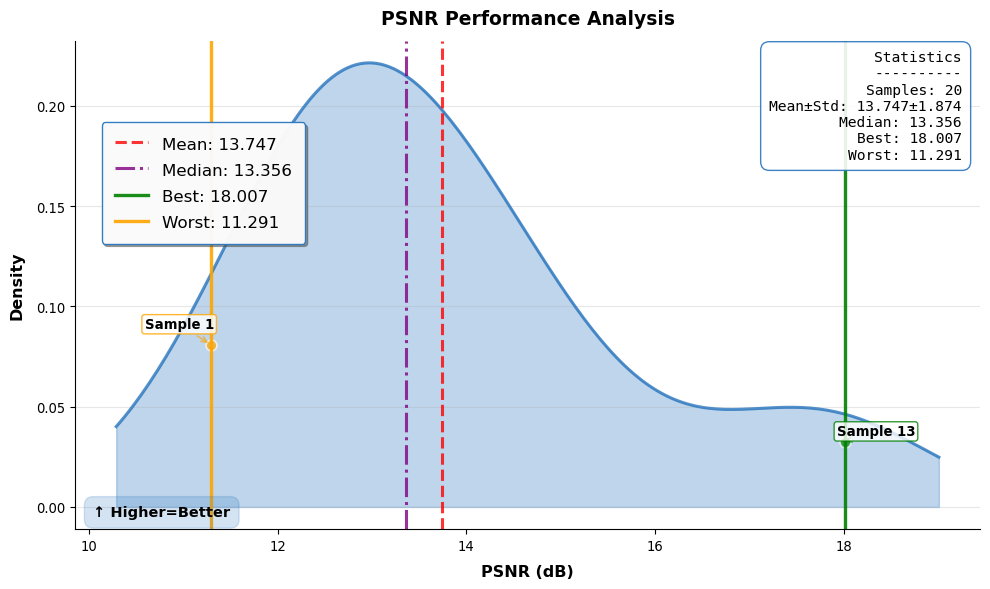

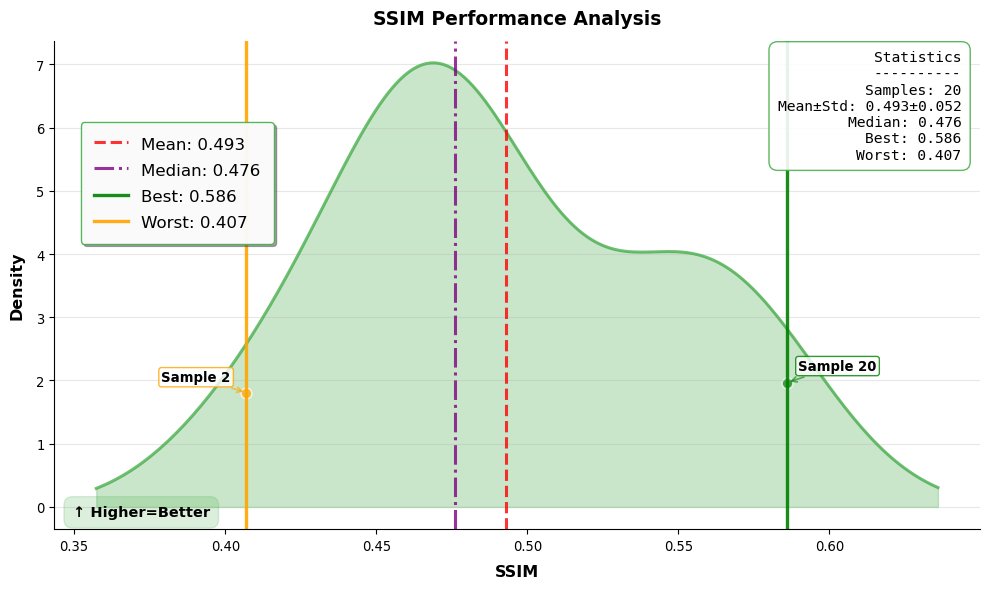

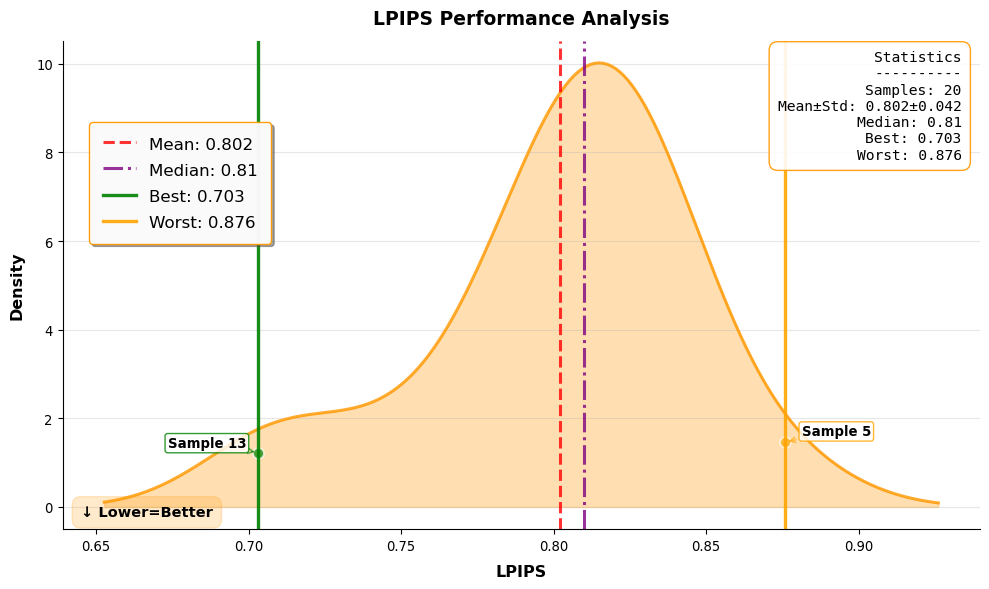

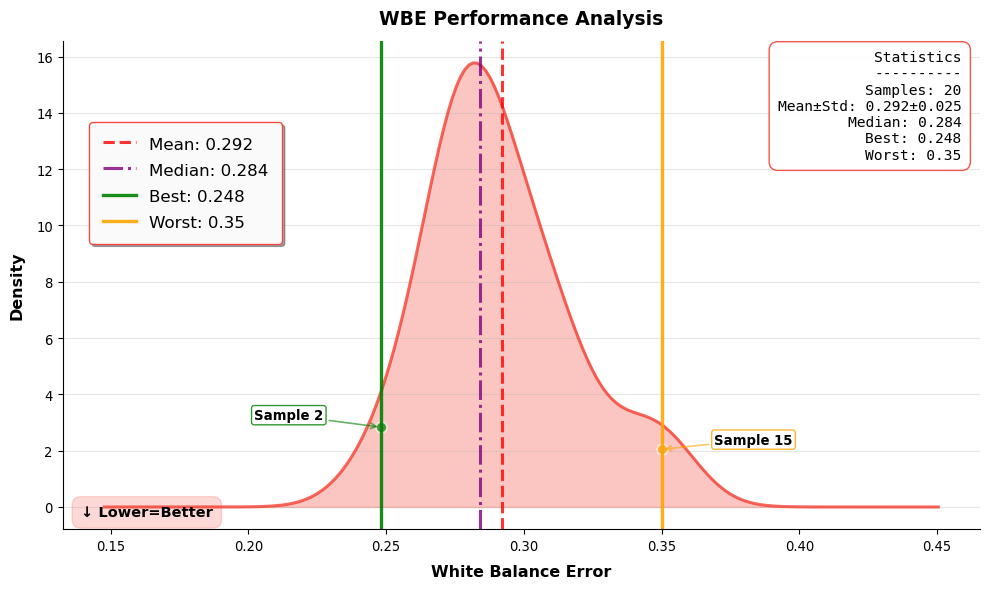

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# -------------------------- 核心配置（齐平框+放大统计面板） --------------------------
EXCEL_PATH = "enhanced_image_evaluation.xlsx"
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.2
plt.rcParams['legend.framealpha'] = 0.95
plt.rcParams['legend.fancybox'] = True
plt.rcParams['legend.shadow'] = True

# 专业配色+配置
METRIC_CONFIG = [
    {
        "name_cn": "PSNR (dB)",
        "name_en": "PSNR",
        "color": "#2A76BE",
        "higher_better": True,
        "ylabel_en": "PSNR (dB)",
        "range_pad": 1.0
    },
    {
        "name_cn": "SSIM",
        "name_en": "SSIM",
        "color": "#4CAF50",
        "higher_better": True,
        "ylabel_en": "SSIM",
        "range_pad": 0.05
    },
    {
        "name_cn": "LPIPS (越小越好)",
        "name_en": "LPIPS",
        "color": "#FF9800",
        "higher_better": False,
        "ylabel_en": "LPIPS",
        "range_pad": 0.05
    },
    {
        "name_cn": "白平衡误差 (WBE)",
        "name_en": "WBE",
        "color": "#F44336",
        "higher_better": False,
        "ylabel_en": "White Balance Error",
        "range_pad": 0.1
    }
]

# -------------------------- 数据加载 --------------------------
def load_data():
    if not os.path.exists(EXCEL_PATH):
        raise FileNotFoundError(f"❌ Excel file not found: {EXCEL_PATH}")
    
    df = pd.read_excel(EXCEL_PATH)
    metric_names_cn = [cfg["name_cn"] for cfg in METRIC_CONFIG]
    missing_cols = [col for col in metric_names_cn if col not in df.columns]
    if missing_cols:
        raise ValueError(f"❌ Missing metric columns: {missing_cols}")
    
    df_clean = df.dropna(subset=metric_names_cn).reset_index(drop=True)
    print(f"✅ Loaded {len(df_clean)} valid samples")
    return df_clean

# -------------------------- 优化版可视化（齐平框+放大统计） --------------------------
def plot_refined_metric(df: pd.DataFrame, metric_cfg: dict):
    name_cn = metric_cfg["name_cn"]
    name_en = metric_cfg["name_en"]
    color = metric_cfg["color"]
    higher_better = metric_cfg["higher_better"]
    ylabel = metric_cfg["ylabel_en"]
    range_pad = metric_cfg["range_pad"]
    
    # 统计量计算
    data = df[name_cn].values
    mean_val = np.mean(data).round(3)
    std_val = np.std(data).round(3)
    median_val = np.median(data).round(3)
    best_val = np.max(data).round(3) if higher_better else np.min(data).round(3)
    worst_val = np.min(data).round(3) if higher_better else np.max(data).round(3)
    best_idx = np.argmax(data) if higher_better else np.argmin(data)
    worst_idx = np.argmin(data) if higher_better else np.argmax(data)
    
    # 紧凑图表尺寸
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. 核密度曲线
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min() - range_pad, data.max() + range_pad, 200)
    density = kde(x_range)
    
    ax.fill_between(x_range, density, alpha=0.3, color=color)
    ax.plot(x_range, density, color=color, linewidth=2.2, alpha=0.8)
    
    # 2. 关键统计线（加粗线条，与图例匹配）
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2.2, alpha=0.8, label=f'Mean: {mean_val}')
    ax.axvline(median_val, color='purple', linestyle='-.', linewidth=2.2, alpha=0.8, label=f'Median: {median_val}')
    ax.axvline(best_val, color='green', linestyle='-', linewidth=2.4, alpha=0.9, label=f'Best: {best_val}')
    ax.axvline(worst_val, color='orange', linestyle='-', linewidth=2.4, alpha=0.9, label=f'Worst: {worst_val}')
    
    # 3. 极值标注（保持清晰）
    best_y_pos = kde(best_val) * 0.7
    worst_y_pos = kde(worst_val) * 0.7
    
    ax.scatter(best_val, best_y_pos, s=60, color='green', alpha=0.7, edgecolors='white', linewidth=1.2)
    ax.annotate(f'Sample {best_idx+1}', 
                xy=(best_val, best_y_pos),
                xytext=(best_val + (range_pad/3 if higher_better else -range_pad/3), best_y_pos * 1.1),
                ha='center', fontsize=9.5, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.6, linewidth=1.2),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='green'))
    
    ax.scatter(worst_val, worst_y_pos, s=60, color='orange', alpha=0.7, edgecolors='white', linewidth=1.2)
    ax.annotate(f'Sample {worst_idx+1}', 
                xy=(worst_val, worst_y_pos),
                xytext=(worst_val - (range_pad/3 if higher_better else -range_pad/3), worst_y_pos * 1.1),
                ha='center', fontsize=9.5, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='orange', alpha=0.6, linewidth=1.2),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='orange'))
    
    # 4. 核心优化1：放大统计面板（字体从8.5→10.5，内边距加大，与左下角框齐平）
    stats_text = (
        f'Statistics\n'
        f'----------\n'
        f'Samples: {len(data)}\n'
        f'Mean±Std: {mean_val}±{std_val}\n'
        f'Median: {median_val}\n'
        f'Best: {best_val}\n'
        f'Worst: {worst_val}'
    )
    
    # 右上角统计框：统一边框样式、加大内边距和字体
    ax.text(0.98, 0.98, stats_text, 
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=10.5,  # 字体放大30%
            fontweight='normal',
            bbox=dict(
                boxstyle='round,pad=0.6',  # 内边距加大（与左下角一致）
                facecolor='white', 
                alpha=0.9, 
                edgecolor=color, 
                linewidth=1.0
            ),
            family='monospace')
    
    # 5. 核心优化2：左下角评价框（统一内边距，与右上角齐平）
    eval_text = '↑ Higher=Better' if higher_better else '↓ Lower=Better'
    ax.text(0.02, 0.02, eval_text,
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=10.5,  # 字体同步放大，保持协调
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.6',  # 内边距与右上角一致（齐平关键）
                facecolor=color, 
                alpha=0.2, 
                edgecolor=color, 
                linewidth=1.0
            ))
    
    # 6. 大图例（保持不变）
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(0.02, 0.85),  # 微调位置，避免遮挡统计框
        fontsize=12,
        labelspacing=0.6,
        handlelength=2.0,
        handleheight=1.0,
        borderpad=0.8,
        frameon=True,
        facecolor='white',
        edgecolor=color
    )
    
    # 7. 图表美化
    ax.set_xlabel(ylabel, fontsize=11.5, fontweight='bold', labelpad=8)
    ax.set_ylabel('Density', fontsize=11.5, fontweight='bold', labelpad=8)
    ax.set_title(f'{name_en} Performance Analysis', fontsize=13.5, fontweight='bold', pad=12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_tick_params(labelsize=9.5)
    ax.yaxis.set_tick_params(labelsize=9.5)
    
    ax.grid(axis='y', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# -------------------------- 主函数 --------------------------
def main():
    df = load_data()
    for cfg in METRIC_CONFIG:
        plot_refined_metric(df, cfg)

# -------------------------- 运行 --------------------------
if __name__ == "__main__":
    main()

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips
import torch
from torch.utils.data import DataLoader, Dataset
from typing import Dict, Tuple, List, Optional, Union
from model_freetech import RawFormer
import warnings
import imageio  # Added: Align with Web version saving method
warnings.filterwarnings("ignore")

# -------------------------- Configuration Parameters (Identical to single correct code) --------------------------
# Base directory (daylight root directory)
BASE_DIR = "eval_dataset/parking_lot"
# Subdirectory configuration (RAW and RGB files stored separately)
RAW_DIR = os.path.join(BASE_DIR, "RAW")       # RAW file path: eval_dataset/daylight/RAW
RGB_DIR = os.path.join(BASE_DIR, "RGB")       # BMP file path: eval_dataset/daylight/RGB
ENHANCE_DIR = os.path.join(BASE_DIR, "ENHANCE")  # Enhanced image save path: eval_dataset/daylight/ENHANCE

# Output configuration
ENHANCED_PREFIX = "enhanced_"
OUTPUT_EXCEL = os.path.join(BASE_DIR, "enhanced_image_evaluation.xlsx")  # Excel saved to daylight directory

# Model and device configuration (Identical to single correct code)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LPIPS_MODEL = "alex"
MODEL_SIZE = "S"  # model_size used during training
MODEL_DIM = 32 if MODEL_SIZE == "S" else 48 if MODEL_SIZE == "B" else 64
CHECKPOINT_PATH = "result/Freetech/weights/model_best.pth"  # Identical to single correct code

# Data configuration (Exactly the same as single correct code!)
RAW_WIDTH = 1920
RAW_HEIGHT = 1280
RGB_WIDTH = 1920
RGB_HEIGHT = 1280
RAW_HEADER_SIZE = 0  # Identical to single correct code
NORMALIZE_RANGE = (0, 1)  # Identical to single correct code

# Enhancement function configuration
RAW_SUFFIX = ".raw"  # RAW file suffix
RGB_SUFFIX = ".bmp"  # GT file suffix (BMP)
SAVE_FORMAT = "bmp"  # Enhanced image save format: only keep BMP (consistent with single code logic)

# ----------------------------------------------------------------

# Ensure output directory exists
os.makedirs(ENHANCE_DIR, exist_ok=True)
print(f"Enhanced images will be saved to: {ENHANCE_DIR}")
print(f"Excel results will be saved to: {OUTPUT_EXCEL}")

class RawRGB_Paired_SeparateDir(Dataset):
    """Dataset class adapted for separate directory storage of RAW and RGB (fully replicate processing logic of single correct code)"""
    def __init__(
        self,
        raw_dir: str,
        rgb_dir: str,
        raw_width: int,
        raw_height: int,
        raw_header_size: int = 0,
        rgb_width: int = 1920,
        rgb_height: int = 1280,
        normalize_range: Tuple[float, float] = (0, 1),
        raw_suffix: str = ".raw",
        rgb_suffix: str = ".bmp"
    ):
        self.raw_dir = raw_dir
        self.rgb_dir = rgb_dir
        self.raw_width = raw_width
        self.raw_height = raw_height
        self.raw_header_size = raw_header_size
        self.rgb_width = rgb_width
        self.rgb_height = rgb_height
        self.min_val, self.max_val = normalize_range
        self.raw_suffix = raw_suffix.lower()
        self.rgb_suffix = rgb_suffix.lower()

        # Scan all RAW files in RAW directory and match corresponding GT files in RGB directory
        self.raw_rgb_pairs = self._scan_paired_files()
        if len(self.raw_rgb_pairs) == 0:
            raise ValueError(
                f"No paired {raw_suffix} and {rgb_suffix} files found\n"
                f"Check directories:\n- RAW: {raw_dir}\n- RGB: {rgb_dir}\n"
                f"Ensure filenames are exactly the same (only suffixes differ)"
            )
        print(f"Found {len(self.raw_rgb_pairs)} valid paired file groups")

    def _scan_paired_files(self) -> List[Tuple[str, str]]:
        """Scan RAW directory and match corresponding GT files in RGB directory"""
        paired_files = []
        
        # Traverse all RAW files in RAW directory
        for raw_filename in os.listdir(self.raw_dir):
            if raw_filename.lower().endswith(self.raw_suffix):
                # Extract base filename (without suffix)
                base_name = os.path.splitext(raw_filename)[0]
                # Construct GT file path in RGB directory
                rgb_filename = f"{base_name}{self.rgb_suffix}"
                rgb_path = os.path.join(self.rgb_dir, rgb_filename)
                raw_path = os.path.join(self.raw_dir, raw_filename)
                
                # Check if GT file exists
                if os.path.exists(rgb_path):
                    paired_files.append((raw_path, rgb_path))
                else:
                    print(f"Warning: Skipping {raw_filename} - {rgb_filename} not found in RGB directory")
        
        return paired_files

    def _load_raw(self, raw_path: str) -> Optional[np.ndarray]:
        """Load RAW file (fully replicate logic of single correct code)"""
        try:
            with open(raw_path, 'rb') as f:
                f.seek(self.raw_header_size)
                raw_data = np.fromfile(f, dtype=np.uint16)
            # Ensure sufficient data volume
            expected_size = self.raw_height * self.raw_width
            if len(raw_data) < expected_size:
                print(f"Warning: RAW file {os.path.basename(raw_path)} is incomplete (actual: {len(raw_data)}, expected: {expected_size})")
                return None
            raw_img = raw_data[:expected_size].reshape(self.raw_height, self.raw_width)
            return raw_img.astype(np.float32)
        except Exception as e:
            print(f"Error: Failed to load RAW file {os.path.basename(raw_path)} - {str(e)}")
            return None

    def _normalize_raw(self, raw_img: np.ndarray) -> np.ndarray:
        """【Core Modification 1】Fully align with Web version RAW preprocessing logic (mandatory black level processing)"""
        ap = 100
        black_level = 512
        max_raw = 16383
        raw_processed = (np.maximum(raw_img.astype(np.float32) - black_level, 0) / (max_raw - black_level)) * ap
        return raw_processed

    def _load_rgb(self, rgb_path: str) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
        """Load GT image (fully replicate logic of single correct code)"""
        try:
            bmp_img = cv2.imread(rgb_path, cv2.IMREAD_COLOR)
            if bmp_img is None:
                print(f"Warning: GT file {os.path.basename(rgb_path)} is corrupted or unreadable")
                return None, None
            
            bmp_img = cv2.cvtColor(bmp_img, cv2.COLOR_BGR2RGB)
            # Resize to training size (consistent with single correct code)
            if bmp_img.shape[:2] != (self.rgb_height, self.rgb_width):
                bmp_img = cv2.resize(bmp_img, (self.rgb_width, self.rgb_height), interpolation=cv2.INTER_LINEAR)
            
            bmp_uint8 = bmp_img.astype(np.uint8)
            bmp_norm = bmp_uint8.astype(np.float32) / 255.0  # Consistent with single correct code: (0,1) range
            return bmp_norm, bmp_uint8
        except Exception as e:
            print(f"Error: Failed to load GT file {os.path.basename(rgb_path)} - {str(e)}")
            return None, None

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, np.ndarray, str]:
        """Return (input_raw, gt_rgb, gt_uint8, base_name) - fully replicate tensor format of single correct code"""
        raw_path, rgb_path = self.raw_rgb_pairs[idx]
        base_name = os.path.splitext(os.path.basename(raw_path))[0]

        # Load data (add validity check)
        raw_img = self._load_raw(raw_path)
        bmp_norm, bmp_uint8 = self._load_rgb(rgb_path)
        if raw_img is None or bmp_norm is None or bmp_uint8 is None:
            raise ValueError(f"Failed to load data for sample {base_name}")

        # RAW normalization (【Core Modification】aligned with Web version)
        raw_norm = self._normalize_raw(raw_img)

        # Convert to tensor (strictly replicate format of single correct code)
        input_raw = torch.from_numpy(raw_norm).unsqueeze(0).float()  # (1, H, W) - consistent with single code
        gt_rgb = torch.from_numpy(bmp_norm.transpose(2, 0, 1)).float()  # (3, H, W) - consistent with single code

        return input_raw, gt_rgb, bmp_uint8, base_name

    def __len__(self) -> int:
        return len(self.raw_rgb_pairs)

# -------------------------- Model Loading (Fully replicate single correct code) --------------------------
def load_enhance_model() -> RawFormer:
    num_virtual_cams = 5  # Consistent with single correct code
    pretrain_mode = False
    model = RawFormer(
        dim=MODEL_DIM,
        use_rep_nr=True,
        num_virtual_cams=num_virtual_cams,
        pretrain_mode=pretrain_mode
    )
    # Load weights (consistent with single correct code)
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
        state_dict = checkpoint["state_dict"]
        new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        model.load_state_dict(new_state_dict, strict=False)
        model = model.to(DEVICE)
        model.eval()
        print(f"Model loaded to {DEVICE}, weight path: {CHECKPOINT_PATH}")
        return model
    except Exception as e:
        print(f"Error: Failed to load model - {str(e)}")
        raise SystemExit(1)

# -------------------------- Data Loading (Adapt to separate directories, keep processing logic of single code) --------------------------
def create_eval_dataset() -> Tuple[DataLoader, List[str]]:
    # Check if RAW and RGB directories exist
    if not os.path.exists(RAW_DIR):
        raise FileNotFoundError(f"RAW directory does not exist: {RAW_DIR}")
    if not os.path.exists(RGB_DIR):
        raise FileNotFoundError(f"RGB directory does not exist: {RGB_DIR}")
    
    dataset = RawRGB_Paired_SeparateDir(
        raw_dir=RAW_DIR,
        rgb_dir=RGB_DIR,
        raw_width=RAW_WIDTH,
        raw_height=RAW_HEIGHT,
        raw_header_size=RAW_HEADER_SIZE,
        rgb_width=RGB_WIDTH,
        rgb_height=RGB_HEIGHT,
        normalize_range=NORMALIZE_RANGE,
        raw_suffix=RAW_SUFFIX,
        rgb_suffix=RGB_SUFFIX
    )
    dataloader = DataLoader(
        dataset,
        batch_size=1,  # Keep batch=1, consistent with single code
        shuffle=False,
        num_workers=0,  # Single thread to avoid data disorder (consistent with single code)
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )
    base_names = [os.path.splitext(os.path.basename(f[0]))[0] for f in dataset.raw_rgb_pairs]
    return dataloader, base_names

# -------------------------- Image Enhancement (【Core Modification 2】Fully align with Web version inference/post-processing logic) --------------------------
def enhance_raw_batch(
    input_raw: torch.Tensor, 
    model: RawFormer, 
    base_name: str,
    save_dir: str = ENHANCE_DIR
) -> Tuple[Optional[np.ndarray], Optional[str], Optional[torch.Tensor]]:
    """Enhance RAW image (fully align with Web version inference logic), save to ENHANCE directory"""
    try:
        # Model inference (exactly the same as Web version)
        with torch.no_grad():
            pred_rgb_tensor = model(input_raw, cam_id=0)  # Keep batch dimension: (1,3,H,W)
            pred_rgb_tensor = torch.clamp(pred_rgb_tensor, 0, 1)  # Consistent with Web version
        
        # Post-processing (fully align with Web version: squeeze() without parameters + transpose(1,2,0) + imageio save)
        pred_rgb_np = pred_rgb_tensor.cpu().numpy()  # (1,3,H,W)
        pred_rgb_np = pred_rgb_np.squeeze()  # Web version uses squeeze() without parameters → (3,H,W)
        pred_rgb_np = pred_rgb_np.transpose((1, 2, 0))  # (H,W,3)
        pred_rgb_np = (pred_rgb_np * 255).astype(np.uint8)  # Consistent value range conversion with Web version
        
        # Save enhanced image (Web version uses imageio to avoid OpenCV BGR/RGB conversion)
        enhanced_path = os.path.join(save_dir, f"{ENHANCED_PREFIX}{base_name}.bmp")
        imageio.imwrite(enhanced_path, pred_rgb_np)  # Directly save RGB without channel conversion
        
        print(f"Enhanced image saved: {os.path.basename(enhanced_path)}")
        return pred_rgb_np, enhanced_path, pred_rgb_tensor  # Return original dimension tensor (1,3,H,W)
    except Exception as e:
        print(f"Error: Failed to enhance image {base_name} - {str(e)}")
        return None, None, None

# -------------------------- Metric Calculation (Fully replicate functions of single correct code) --------------------------
def calculate_psnr_train_style(gt_rgb_tensor: torch.Tensor, pred_rgb_tensor: torch.Tensor) -> float:
    """Fully replicate PSNR calculation logic of single correct code (adapt to Web version dimensions)"""
    # Verify input dimensions (ensure consistency with Web version)
    assert gt_rgb_tensor.shape == pred_rgb_tensor.shape, f"Dimension mismatch: gt={gt_rgb_tensor.shape}, pred={pred_rgb_tensor.shape}"
    assert gt_rgb_tensor.shape[0] == 1, f"Batch dimension error: {gt_rgb_tensor.shape[0]}"
    assert gt_rgb_tensor.shape[1] == 3, f"Channel dimension error: {gt_rgb_tensor.shape[1]}"
    
    # Adapt to Web version dimensions: first squeeze(0) then process
    gt_np = gt_rgb_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)  # (H,W,3)
    pred_np = pred_rgb_tensor.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)  # (H,W,3)
    pred_np = np.clip(pred_np, 0.0, 1.0)
    
    # Convert to uint8 (consistent with single correct code)
    gt_uint8 = (gt_np * 255).astype(np.uint8)
    pred_uint8 = (pred_np * 255).astype(np.uint8)
    
    psnr_value = psnr(gt_uint8, pred_uint8, data_range=255)
    return psnr_value

def calculate_ssim(gt_uint8: np.ndarray, pred_uint8: np.ndarray) -> float:
    """Fully replicate SSIM calculation of single correct code"""
    return ssim(
        gt_uint8, pred_uint8,
        data_range=255,
        channel_axis=2,
        gaussian_weights=True,
        sigma=1.5
    )

def calculate_lpips(gt_uint8: np.ndarray, pred_uint8: np.ndarray, lpips_model) -> float:
    """Fully replicate LPIPS calculation of single correct code"""
    def preprocess(img: np.ndarray) -> torch.Tensor:
        img_norm = (img / 255.0) * 2 - 1  # 0-255 → [-1,1] (consistent with single code)
        return torch.from_numpy(img_norm.transpose((2, 0, 1))).float().unsqueeze(0).to(DEVICE)
    
    gt_tensor = preprocess(gt_uint8)
    pred_tensor = preprocess(pred_uint8)
    
    with torch.no_grad():
        dist = lpips_model(gt_tensor, pred_tensor).item()
    return dist

def calculate_white_balance_error(gt_uint8: np.ndarray, pred_uint8: np.ndarray) -> float:
    """Fully replicate WBE calculation of single correct code"""
    gt = gt_uint8.astype(np.float32) / 255.0
    pred = pred_uint8.astype(np.float32) / 255.0
    
    # Calculate RGB channel means
    gt_r, gt_g, gt_b = np.mean(gt[..., 0]), np.mean(gt[..., 1]), np.mean(gt[..., 2])
    pred_r, pred_g, pred_b = np.mean(pred[..., 0]), np.mean(pred[..., 1]), np.mean(pred[..., 2])
    
    # Avoid division by zero
    gt_g = max(gt_g, 1e-6)
    pred_g = max(pred_g, 1e-6)
    
    # Calculate R/G, B/G ratio error
    return abs((pred_r/pred_g) - (gt_r/gt_g)) + abs((pred_b/pred_g) - (gt_b/gt_g))

# -------------------------- Main Process (Fully replicate logic of single correct code, only adapt to enhanced function modification) --------------------------
def main():
    print("="*60)
    print(f"Start batch evaluation (RAW processing logic aligned with Web version)")
    print(f"RAW file directory: {RAW_DIR}")
    print(f"GT file directory: {RGB_DIR}")
    print(f"Enhanced image directory: {ENHANCE_DIR}")
    print("="*60)

    # Load enhancement model (consistent with single correct code)
    print("\nLoading enhancement model...")
    enhance_model = load_enhance_model()
    
    # Initialize LPIPS (consistent with single correct code)
    print(f"\nInitializing LPIPS model ({LPIPS_MODEL})...")
    try:
        lpips_model = lpips.LPIPS(net=LPIPS_MODEL).to(DEVICE)
        lpips_model.eval()
    except Exception as e:
        print(f"Error: Failed to initialize LPIPS - {str(e)}")
        return
    
    # Load evaluation dataset (separate directory structure, keep processing logic of single code)
    print("\nLoading evaluation dataset...")
    try:
        eval_dataloader, base_names = create_eval_dataset()
    except (ValueError, FileNotFoundError) as e:
        print(f"Error: {e}")
        return
    
    # Batch processing (process sample by sample, fully replicate logic of single code)
    results = []
    total_samples = len(eval_dataloader)
    print(f"\nStart processing {total_samples} samples...")
    print("="*60)
    
    for idx, (input_raw, gt_rgb, gt_uint8, base_name) in enumerate(eval_dataloader, 1):
        print(f"\n[{idx}/{total_samples}] Processing sample: {base_name}")
        
        try:
            # Move data to device (consistent with single correct code, keep batch dimension)
            input_raw = input_raw.to(DEVICE)  # (1,1,H,W)
            gt_rgb = gt_rgb.to(DEVICE)        # (1,3,H,W) → consistent with single code
            gt_uint8 = gt_uint8.squeeze().numpy()  # (H,W,3) → consistent with single code
            
            # Image enhancement (align with Web version inference logic)
            enhanced_img, enhanced_path, pred_rgb_tensor = enhance_raw_batch(input_raw, enhance_model, base_name)
            if enhanced_img is None or pred_rgb_tensor is None:
                continue
            
            # Dimension verification (ensure enhanced image has same size as GT)
            if gt_uint8.shape != enhanced_img.shape:
                print(f"Warning: Dimension mismatch (GT: {gt_uint8.shape[:2]}, Enhanced: {enhanced_img.shape[:2]}), skipping metric calculation")
                continue
            
            # Calculate metrics (fully replicate function calls of single correct code)
            psnr_val = calculate_psnr_train_style(gt_rgb, pred_rgb_tensor)  # Input is (1,3,H,W) tensor
            ssim_val = calculate_ssim(gt_uint8, enhanced_img)
            lpips_val = calculate_lpips(gt_uint8, enhanced_img, lpips_model)
            wbe_val = calculate_white_balance_error(gt_uint8, enhanced_img)
            
            # Record results
            results.append({
                "Sample Name": base_name,
                "RAW File Path": os.path.join(RAW_DIR, f"{base_name}{RAW_SUFFIX}"),
                "GT File Path": os.path.join(RGB_DIR, f"{base_name}{RGB_SUFFIX}"),
                "Enhanced Image Path": enhanced_path,
                "PSNR (dB)": round(psnr_val, 4),
                "SSIM": round(ssim_val, 4),
                "LPIPS (Lower is Better)": round(lpips_val, 4),
                "White Balance Error (WBE)": round(wbe_val, 4)
            })
            
            # Print current results
            print(f"  PSNR: {psnr_val:.4f} dB | SSIM: {ssim_val:.4f} | LPIPS: {lpips_val:.4f} | WBE: {wbe_val:.4f}")
        
        except Exception as e:
            print(f"Error: Failed to process sample {base_name} - {str(e)}")
            continue
    
    # Save Excel results
    if results:
        df = pd.DataFrame(results)
        
        # Added 1: Create average row
        avg_row = {
            "Sample Name": "Average",
            "RAW File Path": "",
            "GT File Path": "",
            "Enhanced Image Path": "",
            "PSNR (dB)": round(df["PSNR (dB)"].mean(), 4),
            "SSIM": round(df["SSIM"].mean(), 4),
            "LPIPS (Lower is Better)": round(df["LPIPS (Lower is Better)"].mean(), 4),
            "White Balance Error (WBE)": round(df["White Balance Error (WBE)"].mean(), 4)
        }
        
        # Added 2: Append average row to DataFrame
        df_with_avg = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)
        
        # Modified 3: Save new DataFrame with average row (change df to df_with_avg)
        df_with_avg.to_excel(OUTPUT_EXCEL, index=False, engine="openpyxl")

        # Statistical summary
        print("\n" + "="*60)
        print("Batch processing completed!")
        print(f"✅ Successfully processed {len(results)}/{total_samples} samples")
        print(f"📊 Evaluation results saved to: {OUTPUT_EXCEL}")
        print(f"🖼️  Enhanced images saved to: {ENHANCE_DIR}")
        print(f"   - Enhanced image prefix: {ENHANCED_PREFIX}")
        print(f"   - Save format: {SAVE_FORMAT.upper()}")
        
        print("\n【Evaluation Metric Statistical Summary】")
        print(f"Average PSNR: {df['PSNR (dB)'].mean():.4f} ± {df['PSNR (dB)'].std():.4f} dB")
        print(f"Average SSIM: {df['SSIM'].mean():.4f} ± {df['SSIM'].std():.4f}")
        print(f"Average LPIPS: {df['LPIPS (Lower is Better)'].mean():.4f} ± {df['LPIPS (Lower is Better)'].std():.4f}")
        print(f"Average WBE: {df['White Balance Error (WBE)'].mean():.4f} ± {df['White Balance Error (WBE)'].std():.4f}")
    else:
        print("\n❌ No samples processed successfully!")

if __name__ == "__main__":
    # Dependency check (added imageio)
    try:
        import pandas
        import openpyxl
        import skimage
        import lpips
        import imageio  # Added check
    except ImportError as e:
        missing_pkg = str(e).split("'")[1]
        print(f"Missing dependency package: {missing_pkg}")
        print("Please install with the following command:")
        print("pip install pandas openpyxl scikit-image lpips torch torchvision opencv-python numpy imageio")
        exit(1)
    
    main()

Enhanced images will be saved to: eval_dataset/parking_lot/ENHANCE
Excel results will be saved to: eval_dataset/parking_lot/enhanced_image_evaluation.xlsx
Start batch evaluation (RAW processing logic aligned with Web version)
RAW file directory: eval_dataset/parking_lot/RAW
GT file directory: eval_dataset/parking_lot/RGB
Enhanced image directory: eval_dataset/parking_lot/ENHANCE

Loading enhancement model...
Model loaded to cuda, weight path: result/Freetech/weights/model_best.pth

Initializing LPIPS model (alex)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /environment/miniconda3/envs/eval_env/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth

Loading evaluation dataset...
Found 63 valid paired file groups

Start processing 63 samples...

[1/63] Processing sample: ['19700101_09_53_46_1920_1280_200490']
Enhanced image saved: enhanced_['19700101_09_53_46_1920_1280_200490'].bmp
  PSNR: 33.3791 dB | SSIM: 0.9682 | LPIPS: 0.0466 | WB